# Single-Core Query Analysis: QueryA vs QueryB RAPL Comparison

This notebook analyzes single-core query timing results with grouped comparisons between queryA and queryB variants.
Data includes per-run RAPL energy measurements and query execution times.

In [5]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
import re
import glob

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

RUNID_FILTERS = ["EF7CBC9D95C16F4F"]

# Load and filter the run summary data
runs_all_df = pd.read_csv('logs/query_timing_single_core.csv')
runs_all_df['run_id'] = runs_all_df['run_id'].astype(str)
available_run_ids = sorted(runs_all_df['run_id'].dropna().unique())
runs_df = runs_all_df[runs_all_df['run_id'].isin(RUNID_FILTERS)].copy()

# Load and filter the perf summary metadata
perf_runs_all_df = pd.read_csv('logs/single_core_perf_runs.csv')
perf_runs_all_df['run_id'] = perf_runs_all_df['run_id'].astype(str)
perf_runs_df = perf_runs_all_df[perf_runs_all_df['run_id'].isin(RUNID_FILTERS)].copy()

print(f'Run ID filters: {RUNID_FILTERS}')
print(f'Available run IDs: {available_run_ids}')
print(f'Loaded {len(runs_df)} filtered runs from query timing data')
print(f'Loaded {len(perf_runs_df)} filtered rows from perf metadata')
print(f'Columns: {list(runs_df.columns)}')
print(f'\nShape: {runs_df.shape}')
print(f'\nFirst few rows:')
display(runs_df.head())
print(f'\nData types:')
print(runs_df.dtypes)

Run ID filters: ['EF7CBC9D95C16F4F']
Available run IDs: ['508D5DE0B3E240F4', 'EF7CBC9D95C16F4F']
Loaded 22 filtered runs from query timing data
Loaded 22 filtered rows from perf metadata
Columns: ['timestamp_utc', 'run_id', 'test_name', 'loop_index', 'loops', 'runs_per_loop', 'total_runs', 'total_elapsed_sec', 'failures', 'rapl_package_j', 'rapl_core_j', 'rapl_gpu_j', 'rapl_dram_j', 'query_dir', 'query_filter', 'sigless_addr', 'run_started_utc']

Shape: (22, 17)

First few rows:


,timestamp_utc,run_id,test_name,loop_index,loops,runs_per_loop,total_runs,total_elapsed_sec,failures,rapl_package_j,rapl_core_j,rapl_gpu_j,rapl_dram_j,query_dir,query_filter,sigless_addr,run_started_utc
2,2026-04-27T21:08:54Z,EF7CBC9D95C16F4F,APX1090-queryA.sql,1,1,100,100,136.642195,0,1056.656372,857.345276,NaN,NaN,queries,all,127.0.0.1:8000,2026-04-27T21:06:37Z
3,2026-04-27T21:11:28Z,EF7CBC9D95C16F4F,APX1090-queryB.sql,1,1,100,100,138.943364,0,1080.791504,877.885498,NaN,NaN,queries,all,127.0.0.1:8000,2026-04-27T21:06:37Z
4,2026-04-27T21:17:57Z,EF7CBC9D95C16F4F,APX1092-queryA.sql,1,1,100,100,374.197073,0,2779.380249,2085.380859,NaN,NaN,queries,all,127.0.0.1:8000,2026-04-27T21:06:37Z
5,2026-04-27T21:24:26Z,EF7CBC9D95C16F4F,APX1092-queryB.sql,1,1,100,100,374.035397,0,2793.769531,2087.252991,NaN,NaN,queries,all,127.0.0.1:8000,2026-04-27T21:06:37Z
6,2026-04-27T21:28:31Z,EF7CBC9D95C16F4F,APX1130-queryA.sql,1,1,100,100,229.804503,0,1813.982117,1462.325500,NaN,NaN,queries,all,127.0.0.1:8000,2026-04-27T21:06:37Z



Data types:
timestamp_utc         object
run_id                object
test_name             object
loop_index             int64
loops                  int64
runs_per_loop          int64
total_runs             int64
total_elapsed_sec    float64
failures               int64
rapl_package_j       float64
rapl_core_j          float64
rapl_gpu_j           float64
rapl_dram_j          float64
query_dir             object
query_filter          object
sigless_addr          object
run_started_utc       object
dtype: object


## Load and Inspect Per-Run RAPL Samples

In [6]:
# List available sample files
sample_dir = Path('logs/single_core_logs/single_core_rapl_samples')
sample_files_all = sorted(sample_dir.glob('*.rapl.csv')) if sample_dir.exists() else []

sample_files = [
    path for path in sample_files_all
    if path.name.split('__', 1)[0] in RUNID_FILTERS
]

if sample_files:
    print(f'Using RUNID-filtered sample files for {RUNID_FILTERS}.')
elif sample_files_all:
    sample_files = sample_files_all
    print('No sample files matched RUNID_FILTERS; using all available sample files for the RAPL sections.')
else:
    print(f'No RAPL sample files found under: {sample_dir}')

print(f'Found {len(sample_files)} RAPL sample files')
if sample_files:
    print(f'\nSample file names (first 5):')
    for f in sample_files[:5]:
        print(f'  {f.name}')

Using RUNID-filtered sample files for ['EF7CBC9D95C16F4F'].
Found 22 RAPL sample files

Sample file names (first 5):
  EF7CBC9D95C16F4F__APX1090-queryA.sql__loop1_run1.rapl.csv
  EF7CBC9D95C16F4F__APX1090-queryB.sql__loop1_run1.rapl.csv
  EF7CBC9D95C16F4F__APX1092-queryA.sql__loop1_run1.rapl.csv
  EF7CBC9D95C16F4F__APX1092-queryB.sql__loop1_run1.rapl.csv
  EF7CBC9D95C16F4F__APX1130-queryA.sql__loop1_run1.rapl.csv


In [7]:
def load_sample(filepath):
    """
    Load a RAPL CSV file and pivot per-metric rows into wide format columns.
    Returns a dataframe with timestamp_sec and energy columns (pkg, cores, gpu, ram).
    """
    df = pd.read_csv(filepath, header=None, comment='#')
    df.columns = ['timestamp_sec', 'value', 'unit', 'metric', 'counter', 'pct', 'col6', 'col7']

    # Pivot: each metric becomes a column
    # Extract metric short names
    df['metric_short'] = df['metric'].str.extract(r'energy-([a-z]+)')[0]

    # For each timestamp, we have multiple metrics; pivot to wide format
    pivoted = df.pivot_table(
        index='timestamp_sec',
        columns='metric_short',
        values='value',
        aggfunc='first'  # In case of duplicates, take first
    )
    pivoted.reset_index(inplace=True)
    pivoted.columns.name = None  # Remove the columns index name

    # Rename columns for clarity
    rename_map = {'cores': 'cores_j', 'dram': 'dram_j', 'gpu': 'gpu_j', 'pkg': 'pkg_j'}
    pivoted.rename(columns=rename_map, inplace=True)

    return pivoted

# Test on a sample file
if not sample_files:
    print('Skipping sample load test because sample_files is empty.')
    sample_test = pd.DataFrame()
else:
    sample_test = load_sample(sample_files[0])
    print(f'Loaded sample with shape {sample_test.shape}')
    print(f'Columns: {list(sample_test.columns)}')
    print(f'\nFirst few rows:')
    display(sample_test.head())

Loaded sample with shape (113144, 5)
Columns: ['timestamp_sec', 'cores_j', 'gpu_j', 'pkg_j', 'ram']

First few rows:


,timestamp_sec,cores_j,gpu_j,pkg_j,ram
0,0.001156,0.01,0.0,0.02,0.0
1,0.004489,0.02,0.0,0.02,0.0
2,0.006290,0.01,0.0,0.02,0.0
3,0.008594,0.01,0.0,0.02,0.0
4,0.011738,0.02,0.0,0.03,0.0


## Full-Loop Window Comparison (1-Second Binned Energy)

Found 22 turbostat files

Grouped into 11 base queries
  APX1090: variants=['queryA', 'queryB']
  APX1092: variants=['queryA', 'queryB']
  APX1130: variants=['queryA', 'queryB']
  APX1145: variants=['queryA', 'queryB']
  APX1173: variants=['queryA', 'queryB']
  APX1186: variants=['queryA', 'queryB']
  APX1225: variants=['queryA', 'queryB']
  APX1278: variants=['queryA', 'queryB']
  PE002: variants=['queryA', 'queryB']
  PE017: variants=['queryA', 'queryB']
  PE019: variants=['queryA', 'queryB']


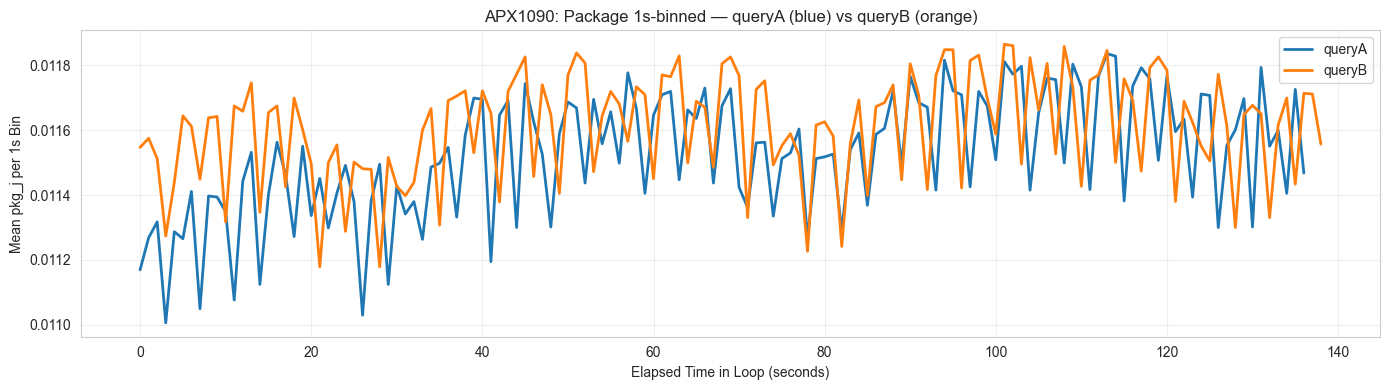

  APX1090: found CPUs [0, 1, 2, 3]


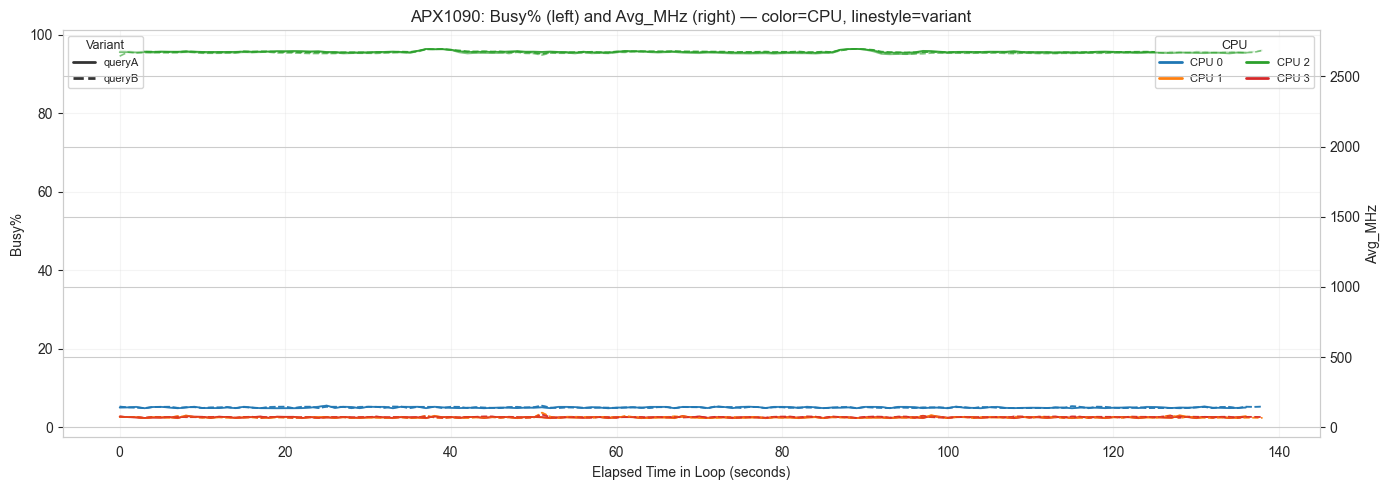

Plotted APX1090


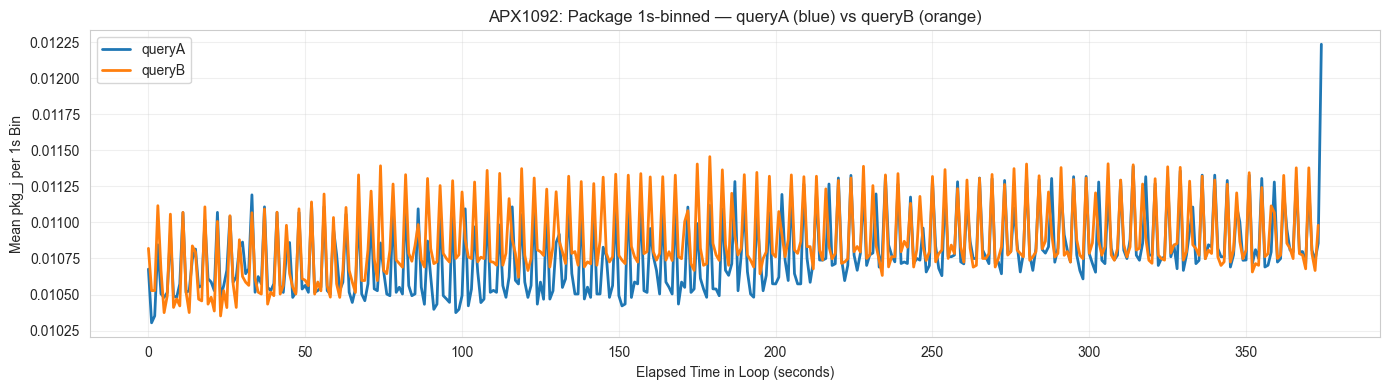

  APX1092: found CPUs [0, 1, 2, 3]


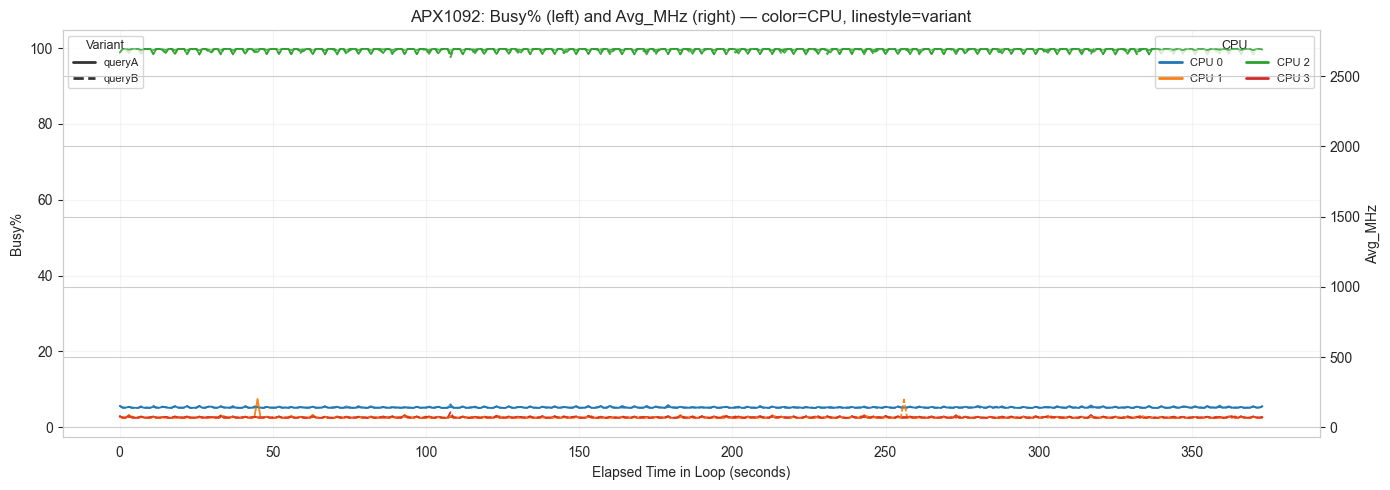

Plotted APX1092


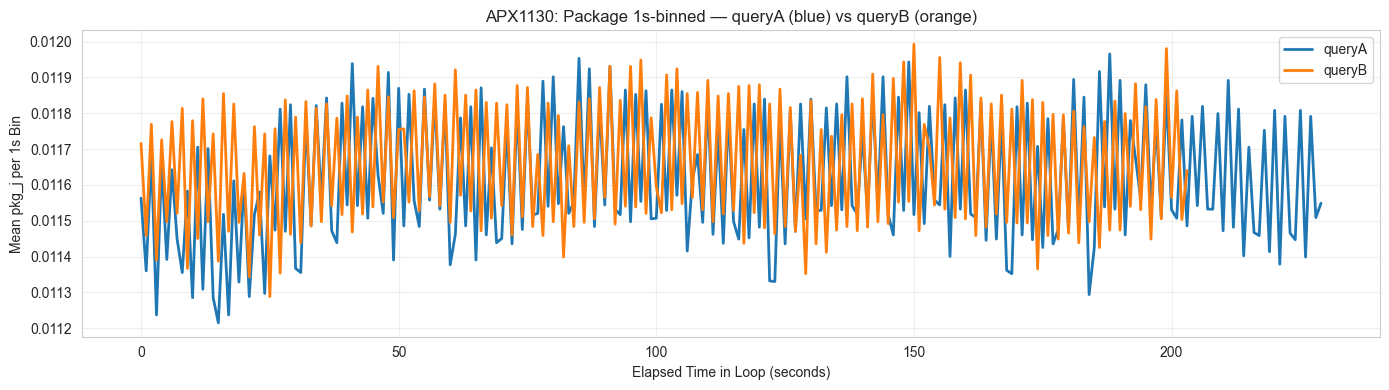

  APX1130: found CPUs [0, 1, 2, 3]


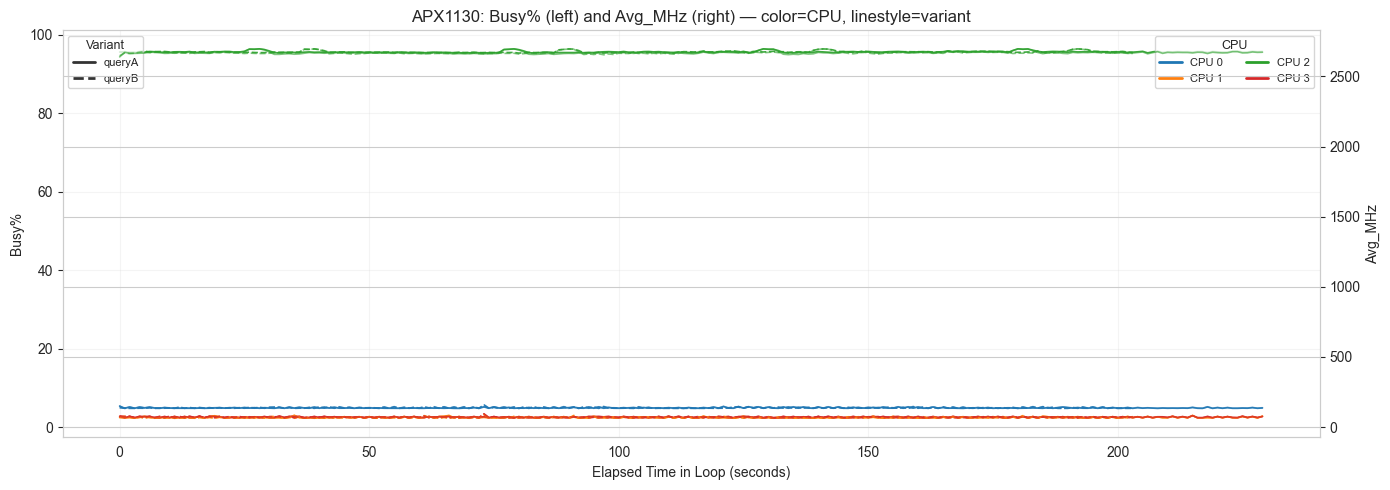

Plotted APX1130


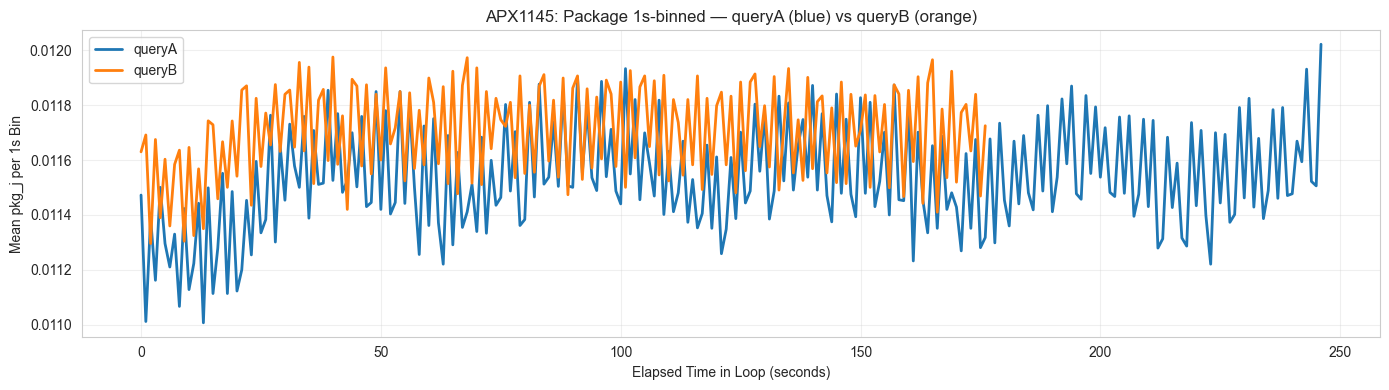

  APX1145: found CPUs [0, 1, 2, 3]


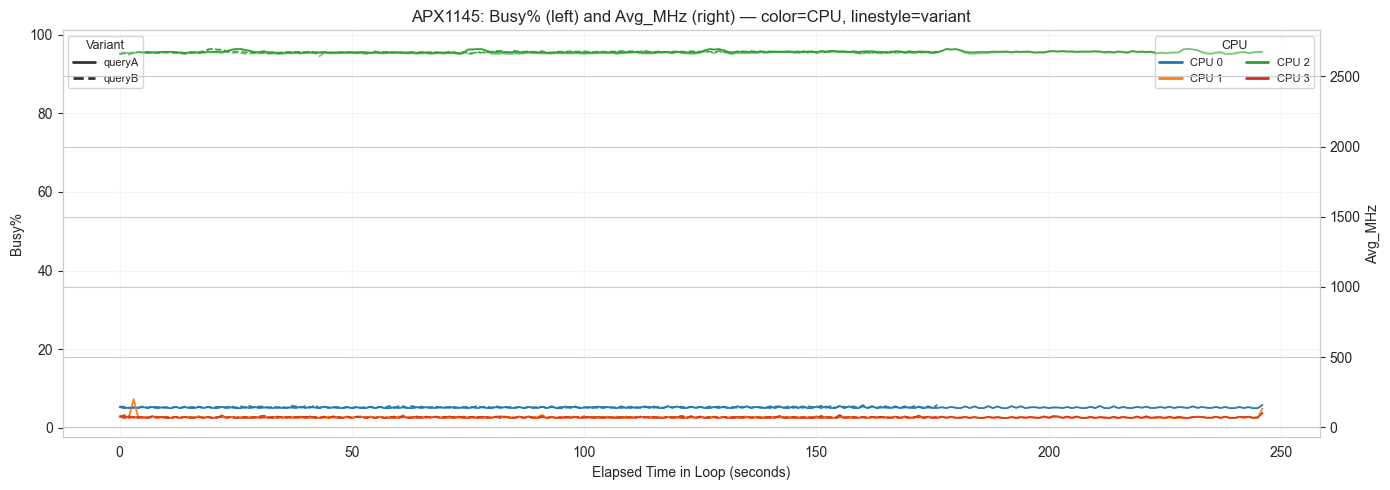

Plotted APX1145


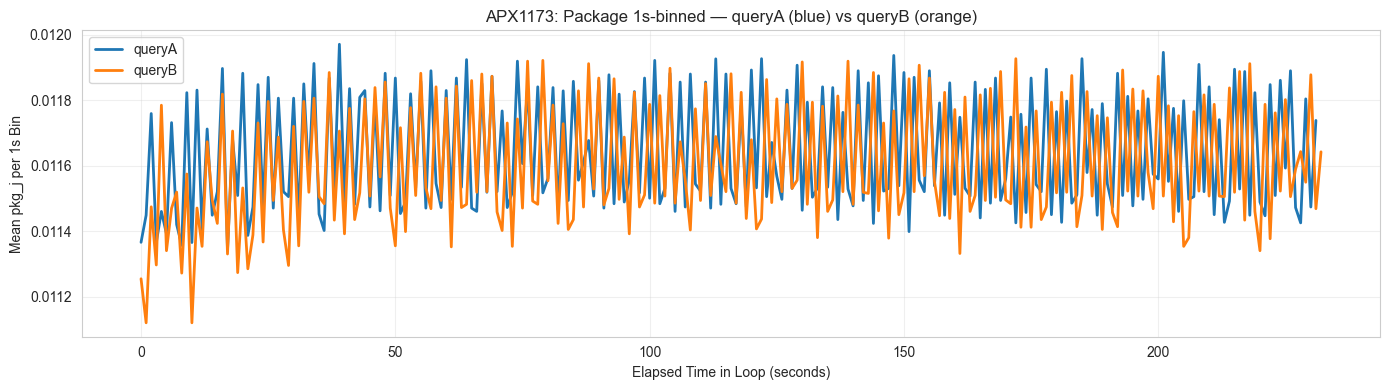

  APX1173: found CPUs [0, 1, 2, 3]


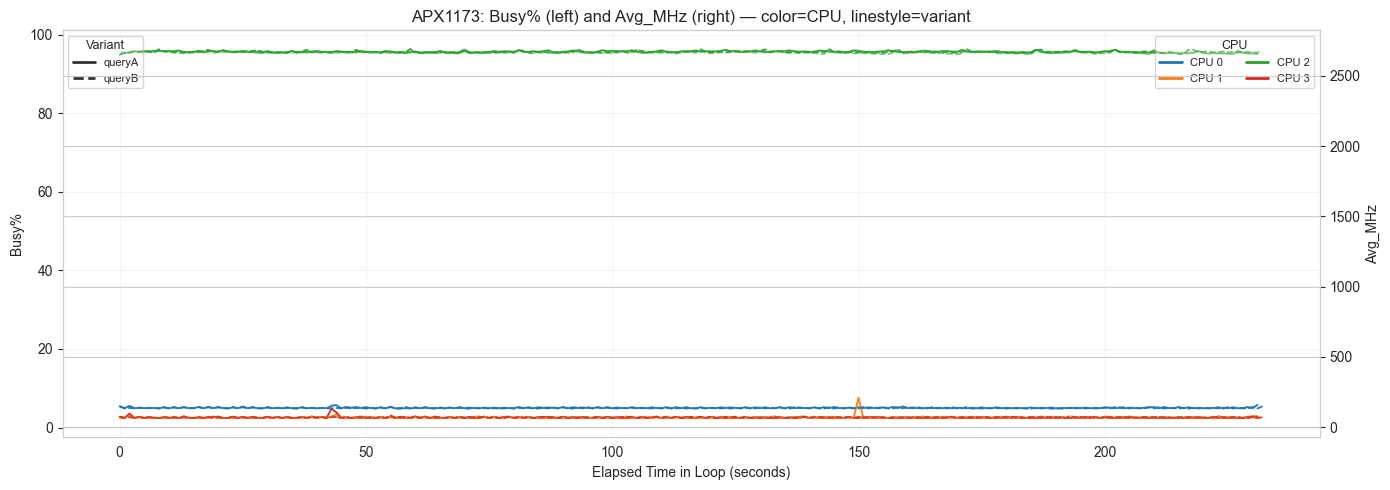

Plotted APX1173


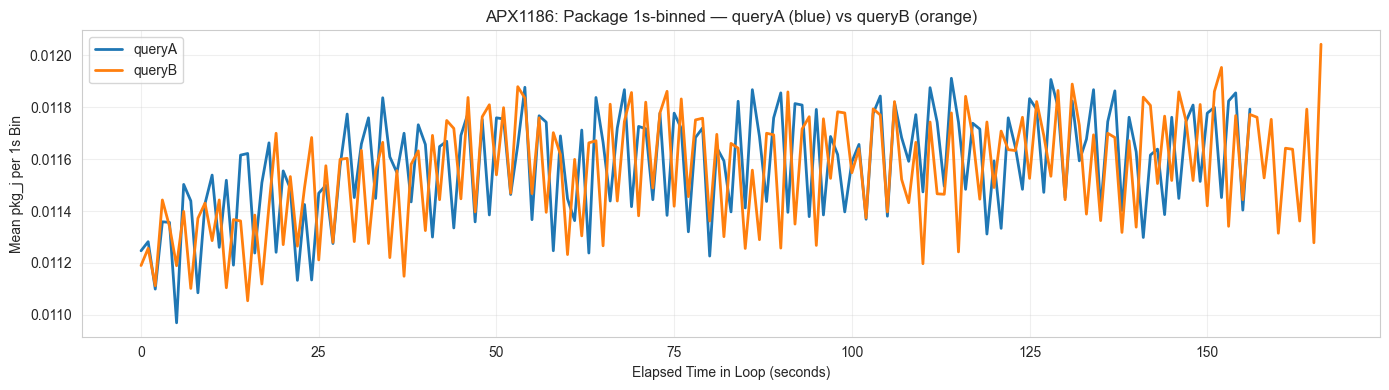

  APX1186: found CPUs [0, 1, 2, 3]


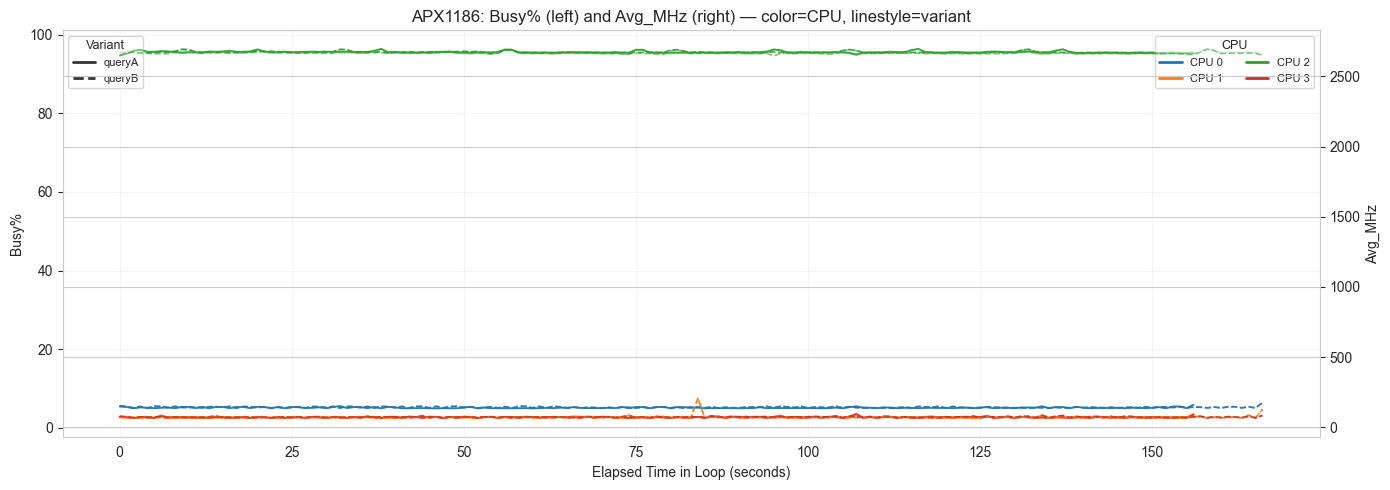

Plotted APX1186


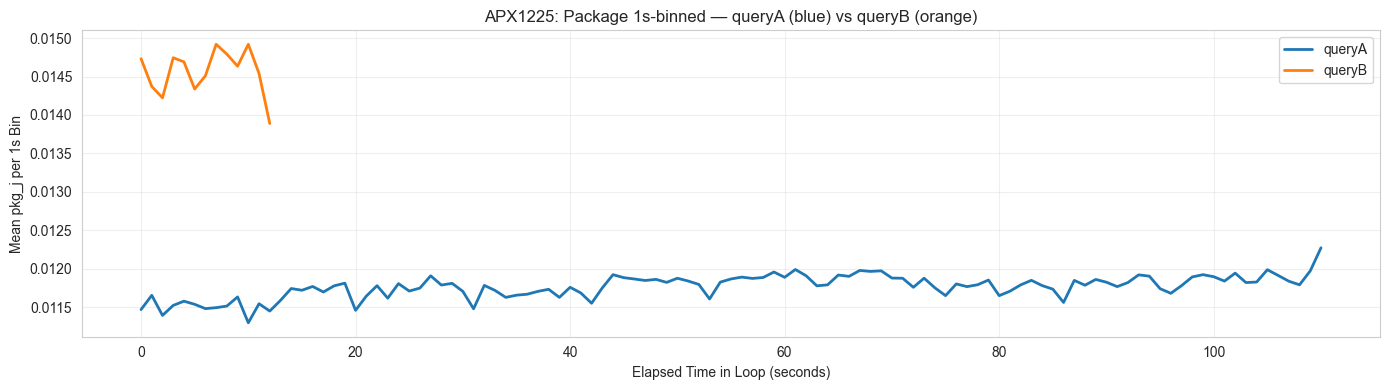

  APX1225: found CPUs [0, 1, 2, 3]


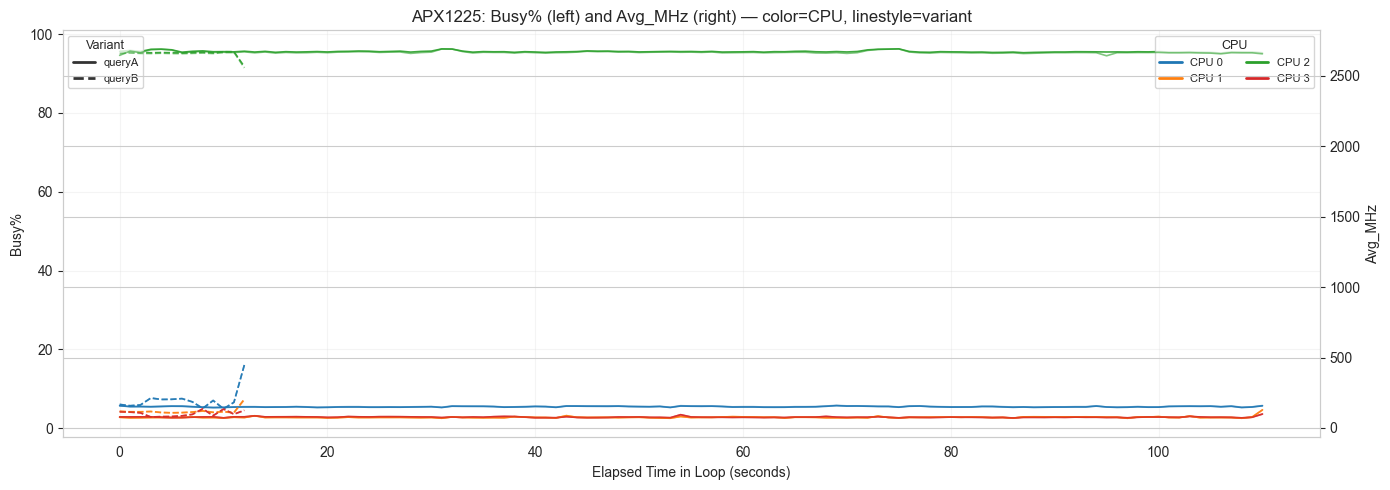

Plotted APX1225


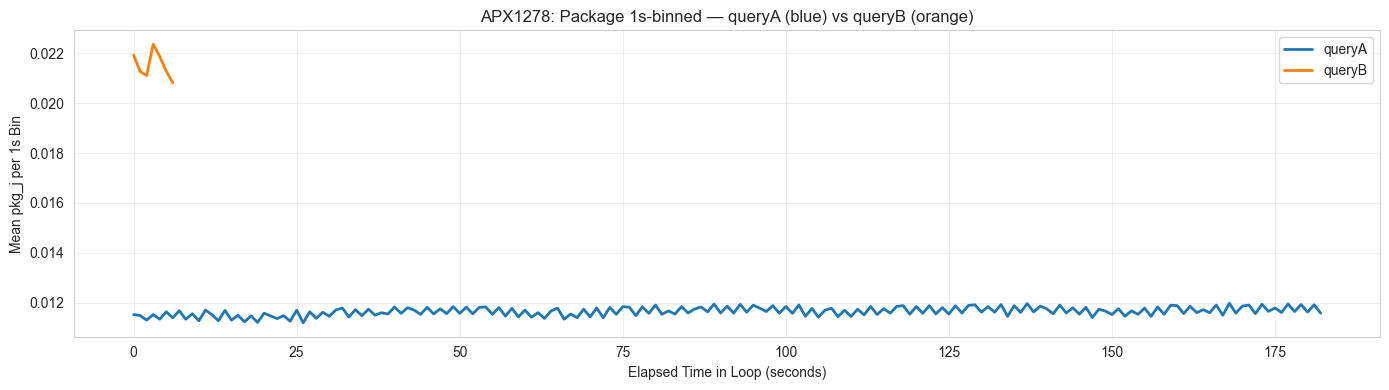

  APX1278: found CPUs [0, 1, 2, 3]


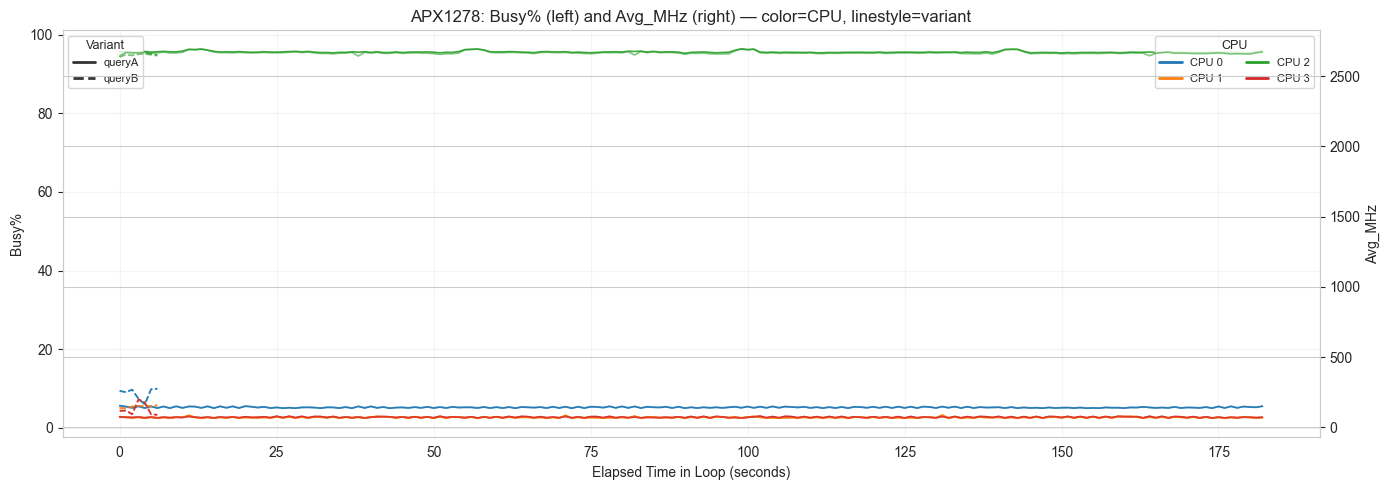

Plotted APX1278


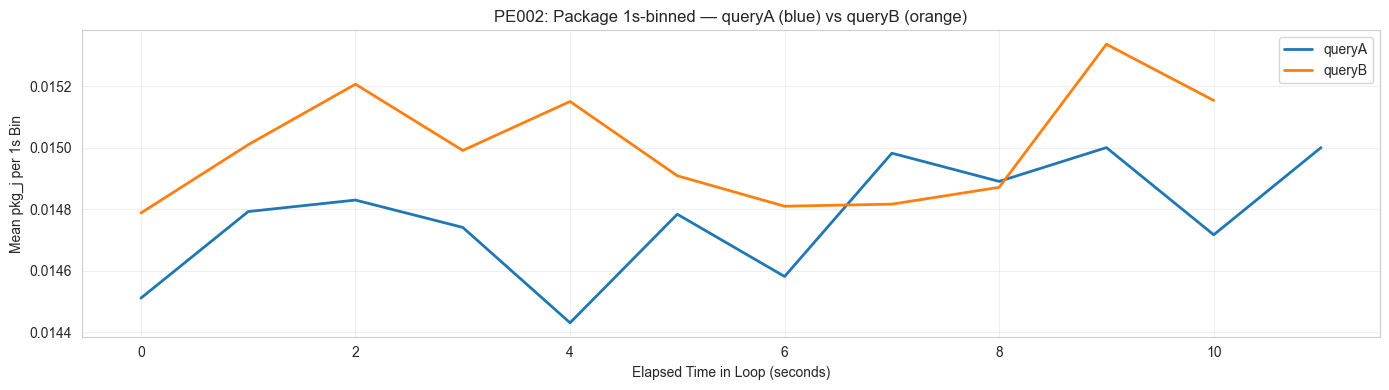

  PE002: found CPUs [0, 1, 2, 3]


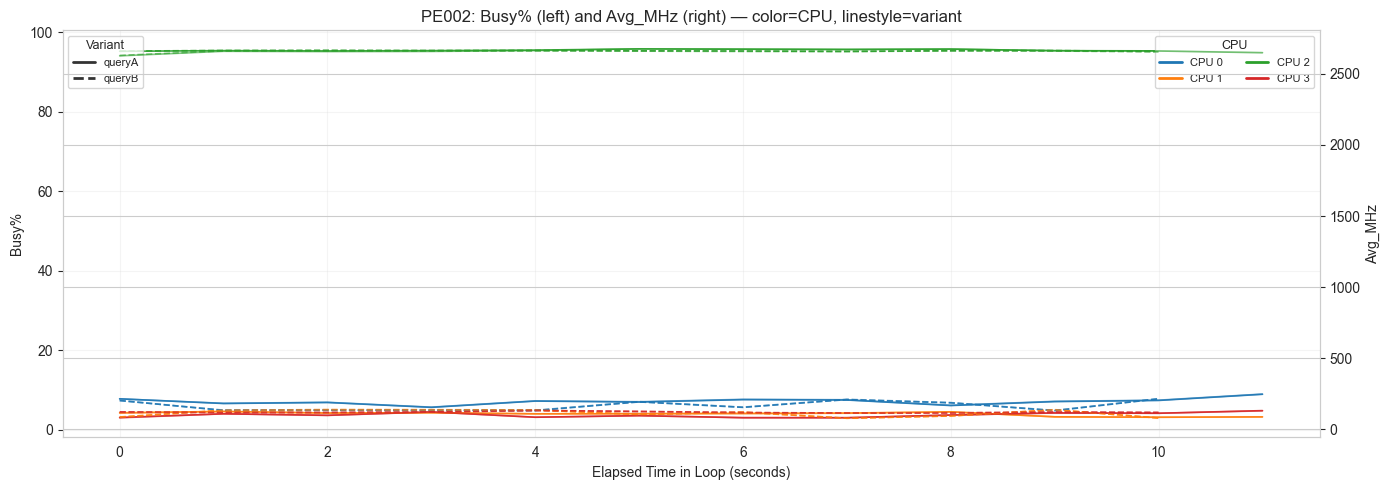

Plotted PE002


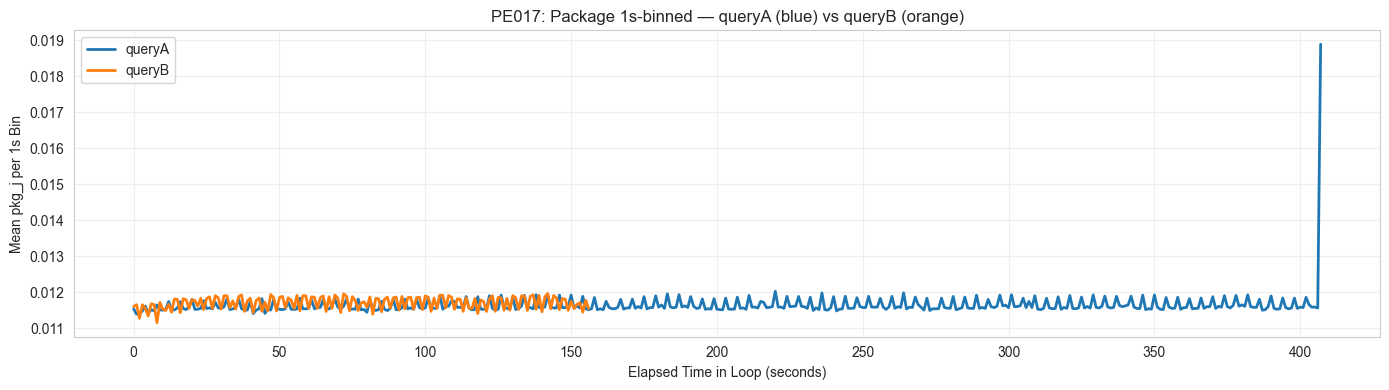

  PE017: found CPUs [0, 1, 2, 3]


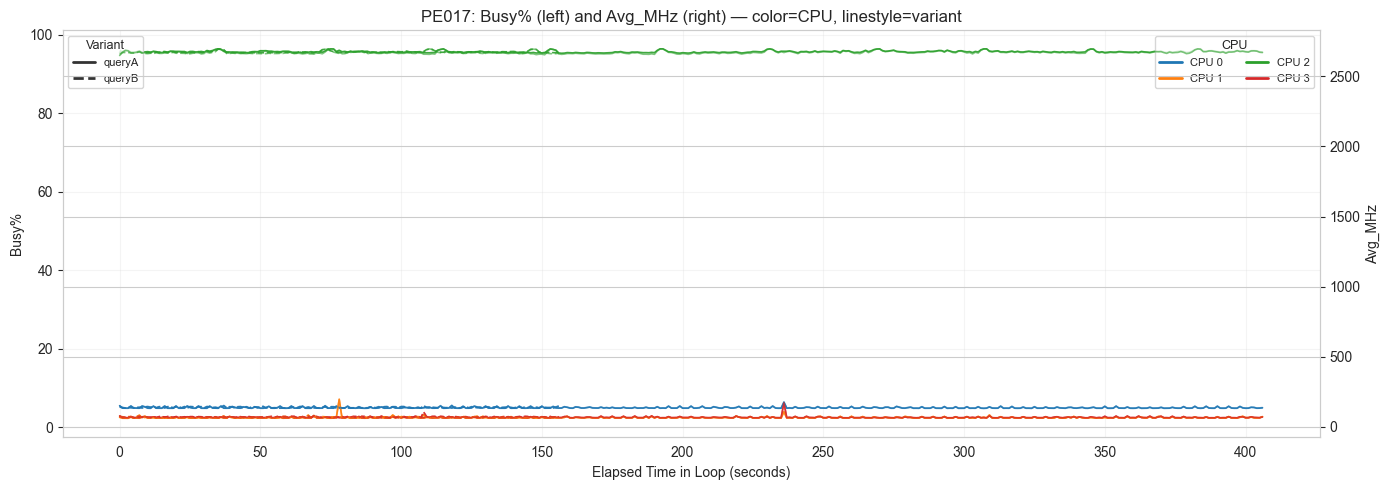

Plotted PE017


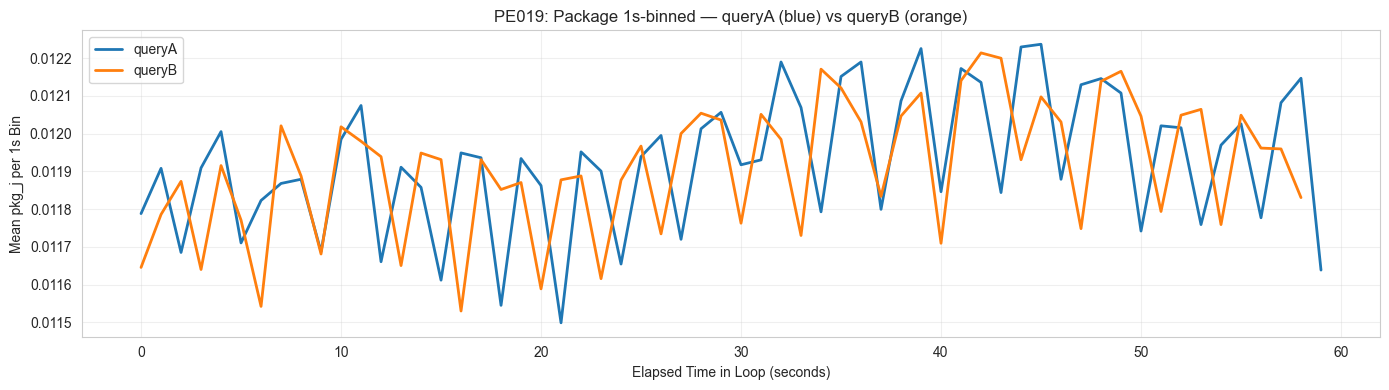

  PE019: found CPUs [0, 1, 2, 3]


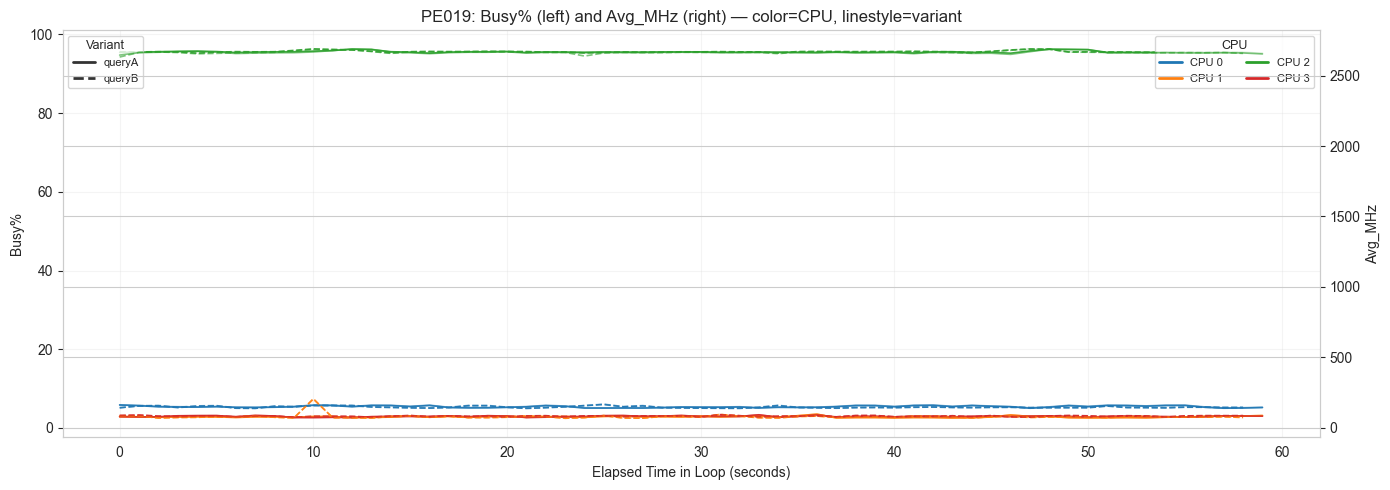

Plotted PE019


In [8]:
# Two separate plots per base query:
# 1) Package power (1s bins) with queryA/queryB overlaid on same plot
# 2) Turbostat metrics with all CPUs on one plot

from matplotlib.lines import Line2D

# Turbostat parsing adapted from detailed_perf_analysis (whitespace-separated)
def parse_turbostat_file(path):
    """Parse turbostat CSV with whitespace separator, filter headers, extract data grouped by CPU."""
    try:
        df = pd.read_csv(path, sep=r"\s+", engine="python")
    except Exception as e:
        print(f"Failed to parse {path}: {e}")
        return {}
    
    # Filter out header rows where Core column repeats "Core"
    if "Core" in df.columns:
        df = df[df["Core"].astype(str) != "Core"].copy()
    
    # Convert numeric columns
    num_cols = ["PkgWatt", "CorWatt", "RAMWatt", "Avg_MHz", "Bzy_MHz", "Busy%", "IPC"]
    for c in num_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    
    # Get CPU column and convert to numeric
    if "CPU" not in df.columns:
        return {}
    
    df["CPU_num"] = pd.to_numeric(df["CPU"], errors="coerce")
    df = df.dropna(subset=["CPU_num"])
    
    # Group by CPU number and return dict
    cpu_groups = {}
    for cpu_num in sorted(df["CPU_num"].unique()):
        cpu_data = df[df["CPU_num"] == cpu_num].copy()
        if not cpu_data.empty:
            cpu_groups[int(cpu_num)] = cpu_data
    
    return cpu_groups


# Find all turbostat files in the perf runs directory
turbostat_dir = Path('logs/single_core_logs/single_core_perf_runs')
turbostat_files_all = sorted(turbostat_dir.glob('*.turbostat.csv')) if turbostat_dir.exists() else []

# Filter by run ID
turbostat_files = [f for f in turbostat_files_all if f.name.split('__')[0] in RUNID_FILTERS]

if not turbostat_files:
    print(f"No turbostat files found in {turbostat_dir} matching run IDs {RUNID_FILTERS}")
else:
    print(f"Found {len(turbostat_files)} turbostat files")

# Build mapping: base_query_name -> variant -> files
# From filename like: 508D5DE0B3E240F4__APX1145-queryA.sql.turbostat.csv
base_query_groups = {}  # {base_query: {variant: [rapl_files, turbostat_file]}}

for rapl_file in sample_files:
    # Extract: run_id, query_name from rapl filename
    match = re.match(r"([A-F0-9]+)__(.+)\.rapl\.csv", rapl_file.name)
    if not match:
        continue
    run_id, query_spec = match.groups()
    
    # Remove loop/run info from query spec (e.g., "APX1145-queryA.sql__loop1_run1" -> "APX1145-queryA.sql")
    query_spec_clean = re.sub(r'__loop\d+_run\d+$', '', query_spec)
    
    # Parse query_spec like "APX1145-queryA.sql" -> base_name="APX1145", variant="queryA"
    if '-queryA' in query_spec_clean:
        base_name = query_spec_clean.replace('-queryA', '').replace('.sql', '')
        variant = 'queryA'
    elif '-queryB' in query_spec_clean:
        base_name = query_spec_clean.replace('-queryB', '').replace('.sql', '')
        variant = 'queryB'
    else:
        continue
    
    # Find corresponding turbostat file (remove __loop*_run* suffix and convert .rapl.csv to .turbostat.csv)
    turb_file_name = re.sub(r'__loop\d+_run\d+\.rapl\.csv$', '.turbostat.csv', rapl_file.name)
    turb_file = turbostat_dir / turb_file_name
    
    key = base_name
    if key not in base_query_groups:
        base_query_groups[key] = {}
    if variant not in base_query_groups[key]:
        base_query_groups[key][variant] = {'rapl': [], 'turb': []}
    
    base_query_groups[key][variant]['rapl'].append(rapl_file)
    if turb_file.exists():
        base_query_groups[key][variant]['turb'].append(turb_file)

print(f"\nGrouped into {len(base_query_groups)} base queries")
for q, vgroups in base_query_groups.items():
    print(f"  {q}: variants={list(vgroups.keys())}")

# Plot per base query
for base_query in sorted(base_query_groups.keys()):
    vgroups = base_query_groups[base_query]
    
    # ----- PLOT 1: Package power with A/B overlay -----
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.set_title(f"{base_query}: Package 1s-binned — queryA (blue) vs queryB (orange)")
    
    color_map = {'queryA': '#1f77b4', 'queryB': '#ff7f0e'}
    
    for variant in sorted(vgroups.keys()):
        rapl_files = vgroups[variant]['rapl']
        if not rapl_files:
            continue
        
        # Load and concatenate all runs for this variant
        all_pkg_vals = []
        all_times = []
        t_offset = 0.0
        
        for rapl_file in sorted(rapl_files):
            df = load_sample(rapl_file)
            if df.empty or 'timestamp_sec' not in df.columns or 'pkg_j' not in df.columns:
                continue
            df = df[['timestamp_sec', 'pkg_j']].dropna().sort_values('timestamp_sec').copy()
            if len(df) < 2:
                continue
            
            t = df['timestamp_sec'].to_numpy(dtype=float) - df['timestamp_sec'].iloc[0]
            v = df['pkg_j'].to_numpy(dtype=float)
            all_times.append(t + t_offset)
            all_pkg_vals.append(v)
            t_offset += t[-1]
        
        if all_times:
            t_concat = np.concatenate(all_times)
            v_concat = np.concatenate(all_pkg_vals)
            
            # Bin to 1-second
            sec = np.floor(t_concat).astype(int)
            binned_df = pd.DataFrame({'sec': sec, 'pkg': v_concat}).groupby('sec', as_index=False).mean()
            
            ax.plot(binned_df['sec'], binned_df['pkg'],
                   color=color_map.get(variant, '#333'), linewidth=2, label=variant)
    
    ax.set_xlabel('Elapsed Time in Loop (seconds)')
    ax.set_ylabel('Mean pkg_j per 1s Bin')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # ----- PLOT 2: Turbostat metrics with all CPUs on one plot -----
    # First, collect all unique CPU numbers across all turbostat files
    all_cpus = set()
    for variant in vgroups.keys():
        turb_files = vgroups[variant]['turb']
        for turb_file in turb_files:
            cpu_groups = parse_turbostat_file(turb_file)
            all_cpus.update(cpu_groups.keys())
    
    all_cpus = sorted(list(all_cpus))
    
    if not all_cpus:
        print(f"  {base_query}: no CPU data found in turbostat files")
        continue
    
    print(f"  {base_query}: found CPUs {all_cpus}")
    
    fig, ax_busy = plt.subplots(figsize=(14, 5))
    ax_mhz = ax_busy.twinx()
    
    ax_busy.set_title(
        f"{base_query}: Busy% (left) and Avg_MHz (right) — color=CPU, linestyle=variant"
    )
    
    cpu_palette = sns.color_palette("tab10", n_colors=max(len(all_cpus), 1))
    cpu_colors = {cpu: cpu_palette[i % len(cpu_palette)] for i, cpu in enumerate(all_cpus)}
    variant_styles = {"queryA": "-", "queryB": "--"}
    
    for variant in sorted(vgroups.keys()):
        turb_files = vgroups[variant]['turb']
        if not turb_files:
            print(f"    {base_query} {variant}: no turbostat files")
            continue
        
        for cpu_num in all_cpus:
            all_busy = []
            all_mhz = []
            time_offset_sec = 0
            
            for turb_file in sorted(turb_files):
                cpu_groups = parse_turbostat_file(turb_file)
                if cpu_num not in cpu_groups:
                    continue
                
                cpu_data = cpu_groups[cpu_num].copy()
                
                # Get Busy% and Avg_MHz columns (case-insensitive search)
                busy_col = next((c for c in cpu_data.columns if c.lower() in ('busy%', 'busy')), None)
                mhz_col = next((c for c in cpu_data.columns if c.lower() in ('avg_mhz', 'avgmhz')), None)
                
                if busy_col is None and mhz_col is None:
                    continue
                
                # Use row index as time (assume each row is one second)
                cpu_data['sec'] = np.arange(len(cpu_data)) + time_offset_sec
                
                # Bin to seconds (usually already 1 row per second in turbostat)
                if busy_col:
                    busy_binned = cpu_data.groupby('sec')[busy_col].mean()
                    all_busy.append(busy_binned)
                if mhz_col:
                    mhz_binned = cpu_data.groupby('sec')[mhz_col].mean()
                    all_mhz.append(mhz_binned)
                
                # Update offset for next file
                time_offset_sec += len(cpu_data) + 1
            
            if all_busy or all_mhz:
                color = cpu_colors.get(cpu_num, '#333')
                style = variant_styles.get(variant, '-')
                if all_busy:
                    combined_busy = pd.concat(all_busy).groupby(level=0).mean()
                    ax_busy.plot(
                        combined_busy.index,
                        combined_busy.values,
                        color=color,
                        linestyle=style,
                        linewidth=1.2,
                        alpha=0.9,
                    )
                if all_mhz:
                    combined_mhz = pd.concat(all_mhz).groupby(level=0).mean()
                    ax_mhz.plot(
                        combined_mhz.index,
                        combined_mhz.values,
                        color=color,
                        linestyle=style,
                        linewidth=1.2,
                        alpha=0.6,
                    )
    
    ax_busy.set_xlabel('Elapsed Time in Loop (seconds)')
    ax_busy.set_ylabel('Busy%')
    ax_mhz.set_ylabel('Avg_MHz')
    ax_busy.grid(True, alpha=0.2)
    
    cpu_handles = [
        Line2D([0], [0], color=cpu_colors[cpu], lw=2, label=f"CPU {cpu}")
        for cpu in all_cpus
    ]
    variant_handles = [
        Line2D([0], [0], color='#333', linestyle=variant_styles[v], lw=2, label=v)
        for v in sorted(vgroups.keys())
        if v in variant_styles
    ]
    
    legend1 = ax_busy.legend(
        handles=cpu_handles,
        title='CPU',
        loc='upper right',
        ncol=2,
        fontsize=8,
        title_fontsize=9,
    )
    ax_busy.add_artist(legend1)
    if variant_handles:
        ax_busy.legend(
            handles=variant_handles,
            title='Variant',
            loc='upper left',
            fontsize=8,
            title_fontsize=9,
        )
    
    plt.tight_layout()
    plt.show()
    
    print(f"Plotted {base_query}")
